In [1]:
import os

import cartopy.crs as ccrs
import cmcrameri as cmc  # noqa: F401
import dask
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from dask.diagnostics import ProgressBar
from matplotlib.animation import FuncAnimation
from metpy.units import units
from unseen_awg.plotting_utils import map_plot_without_frame_with_bounds

with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [2]:
impacts = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_reforecasts/combined_7d1d3d97.zarr",
    )
).chunk(init_time=1, ensemble_member=1)

impacts["tp"] = (
    impacts["tp"]
    .where(impacts["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)

circulation = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_circulation_reforecasts/combined_5e06172f.zarr",
    )
)

In [3]:
trajectory_tau_30 = xr.open_dataset(
    os.path.join(
        paths["dir_simulations"],
        "wg_reforecasts_5e06172f_f40e9460_1e69bda9_d13ad10f/0_2.5_30/trajectory.nc",
    )
).isel(out_time=slice(None, 2000))  # limit for memory reasons.

In [4]:
circulation_traj = circulation.sel(trajectory_tau_30)["geopotential_height"].load()
with dask.config.set(scheduler="synchronous"), ProgressBar():
    impacts_traj = impacts.sel(trajectory_tau_30).load()

[########################################] | 100% Completed | 410.74 s


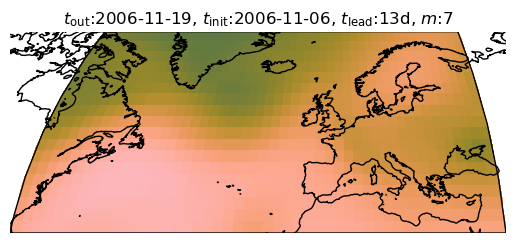

In [5]:
n_frames = 200
tau = 30  # transition interval
n_times = len(circulation_traj.out_time)
pause_repeats = 5  # extra frames to linger at each transition boundary

# --- Build frame sequence with pauses at transitions ---
transition_indices = set()
frame_sequence = []
for i in range(n_times):
    if i > 0 and i % tau == 0:
        # Mark both sides of the boundary
        transition_indices.add(i - 1)
        transition_indices.add(i)
        # Repeat boundary frames to create a pause
        frame_sequence.extend([i - 1] * pause_repeats)
        frame_sequence.extend([i] * pause_repeats)
    else:
        frame_sequence.append(i)

# --- Set up figure ---
fig, axis = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.Robinson()))

# Persistent figure-level elements (survive axis.clear())
transition_text = fig.text(
    0.5,
    0.02,
    "● TRANSITION",
    ha="center",
    fontsize=14,
    color="red",
    fontweight="bold",
    visible=False,
)
fig.patch.set_edgecolor("none")


# --- Update function ---
def update(seq_idx):
    frame = frame_sequence[seq_idx]
    is_transition = frame in transition_indices

    axis.clear()

    circulation_frame = circulation_traj.isel(out_time=frame)

    map_plot_without_frame_with_bounds(
        ax=axis,
        da=circulation_frame,
        cmap="cmc.batlow",
        vmin=440,
        vmax=610,
        add_colorbar=False,
    )

    ot = circulation_frame.out_time.squeeze().values.astype("datetime64[ns]")
    it = circulation_frame.init_time.squeeze().values.astype("datetime64[ns]")
    lt = int(
        circulation_frame.lead_time.squeeze().values.astype("timedelta64[ns]")
        / np.timedelta64(1, "D")
    )
    em = circulation_frame.ensemble_member.squeeze().values

    axis.set_title(
        r"$t_\mathrm{out}$:"
        + np.datetime_as_string(ot.squeeze(), unit="D")
        + r", $t_\mathrm{init}$:"
        + np.datetime_as_string(it.squeeze(), unit="D")
        + r", $t_\mathrm{lead}$:"
        + f"{lt}"
        + r"d, $m$:"
        + f"{em}"
    )

    # Highlight transitions
    transition_text.set_visible(is_transition)
    if is_transition:
        fig.patch.set_edgecolor("red")
        fig.patch.set_linewidth(5)
    else:
        fig.patch.set_edgecolor("none")
        fig.patch.set_linewidth(0)


ani = FuncAnimation(fig, update, frames=n_frames, interval=200, repeat_delay=2000)
ani.save(
    os.path.join(paths["dir_images"], "animation.gif"),
    writer="pillow",
    fps=5,
)


In [6]:
cmaps = {
    "t2m": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
    },
    "mn2t": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
    },
    "mx2t": {
        "cmap": plt.get_cmap("cmc.vik"),
        "norm": mpl.colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=40),
    },
    "tp": {
        "cmap": plt.get_cmap("cmc.oslo_r"),
        "norm": mpl.colors.LogNorm(vmin=1, vmax=40),
    },
}

In [7]:
impacts_traj

<xarray.Dataset> Size: 840MB
Dimensions:          (out_time: 2000, latitude: 105, longitude: 125)
Coordinates:
  * out_time         (out_time) datetime64[ns] 16kB 2006-11-19 ... 2012-05-10
    ensemble_member  (out_time) int64 16kB 7 7 7 7 7 7 7 7 7 ... 5 5 5 5 5 5 5 5
    init_time        (out_time) datetime64[ns] 16kB 2006-11-06 ... 2010-04-11
    lead_time        (out_time) timedelta64[ns] 16kB 13 days 14 days ... 31 days
  * latitude         (latitude) float64 840B 71.8 71.4 71.0 ... 31.0 30.6 30.2
  * longitude        (longitude) float64 1kB -9.8 -9.4 -9.0 ... 39.0 39.4 39.8
Data variables:
    mn2t             (out_time, latitude, longitude) float64 210MB -0.1885 .....
    mx2t             (out_time, latitude, longitude) float64 210MB 1.813 ... ...
    t2m              (out_time, latitude, longitude) float64 210MB 1.173 ... ...
    tp               (out_time, latitude, longitude) float64 210MB 1.621 ... 0.0
Attributes:
    Conventions:    CF-1.7
    Title:          Daily aggregate extended ensemble forecast hindcast impac...
    Source:         Contains modified “Extended ensemble forecast hindcast” d...
    Creator:        Jonathan Wider (ORCID: 0000-0002-5185-5768)
    Institution:    Helmholtz Centre for Environmental Research – UFZ
    Creation_date:  2026-04-13 20:11:23
    License:        Creative Commons Attribution 4.0 International

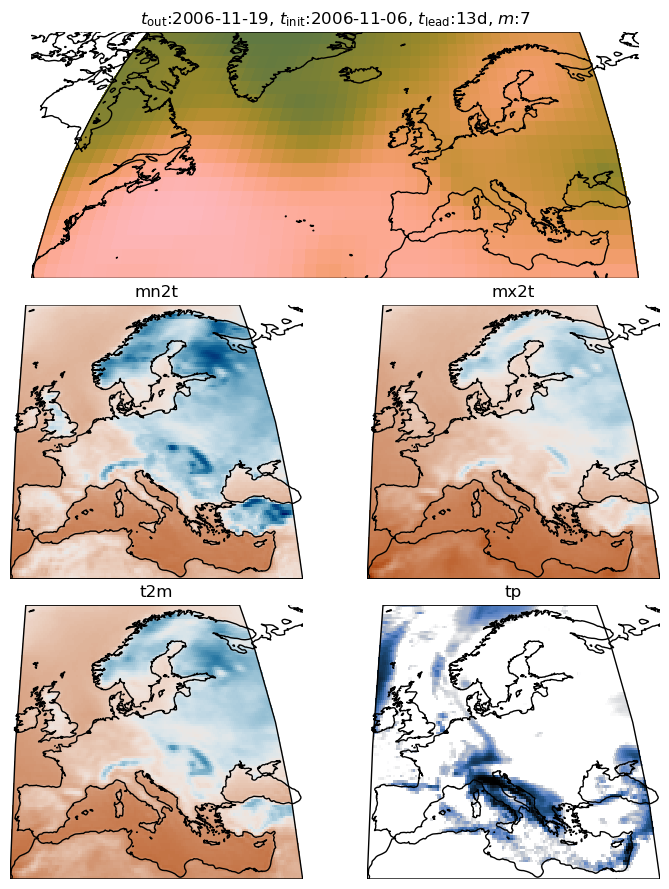

In [8]:
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation

n_frames = 200
tau = 30
n_times = len(circulation_traj.out_time)
pause_repeats = 5

# --- Build frame sequence with transition pauses ---
transition_indices = set()
frame_sequence = []
for i in range(n_times):
    if i > 0 and i % tau == 0:
        transition_indices.add(i - 1)
        transition_indices.add(i)
        frame_sequence.extend([i - 1] * pause_repeats)
        frame_sequence.extend([i] * pause_repeats)
    else:
        frame_sequence.append(i)

fig = plt.figure(figsize=(9, 11))
gs = gridspec.GridSpec(
    3,
    2,
    height_ratios=[0.9, 1, 1],
    hspace=0.1,
    wspace=0.05,
    figure=fig,
)

proj = ccrs.Robinson()

ax_main = fig.add_subplot(gs[0, :], projection=proj)  # spans both columns
ax_bl = fig.add_subplot(gs[1, 0], projection=proj)
ax_br = fig.add_subplot(gs[1, 1], projection=proj)
ax_ll = fig.add_subplot(gs[2, 0], projection=proj)
ax_lr = fig.add_subplot(gs[2, 1], projection=proj)

all_axes = [ax_main, ax_bl, ax_br, ax_ll, ax_lr]

# Persistent figure-level elements (survive ax.clear())
transition_text = fig.text(
    0.5,
    0.01,
    "● TRANSITION",
    ha="center",
    fontsize=14,
    color="red",
    fontweight="bold",
    visible=False,
)


# --- Update function ---
def update(seq_idx):
    frame = frame_sequence[seq_idx]
    is_transition = frame in transition_indices

    for ax in all_axes:
        ax.clear()

    circulation_frame = circulation_traj.isel(out_time=frame)

    m = map_plot_without_frame_with_bounds(
        ax=ax_main,
        da=circulation_frame,
        cmap="cmc.batlow",
        vmin=440,
        vmax=610,
        add_colorbar=False,
    )
    m.set_rasterized(True)

    ot = circulation_frame.out_time.squeeze().values.astype("datetime64[ns]")
    it = circulation_frame.init_time.squeeze().values.astype("datetime64[ns]")
    lt = int(
        circulation_frame.lead_time.squeeze().values.astype("timedelta64[ns]")
        / np.timedelta64(1, "D")
    )
    em = circulation_frame.ensemble_member.squeeze().values

    ax_main.set_title(
        r"$t_\mathrm{out}$:"
        + np.datetime_as_string(ot.squeeze(), unit="D")
        + r", $t_\mathrm{init}$:"
        + np.datetime_as_string(it.squeeze(), unit="D")
        + r", $t_\mathrm{lead}$:"
        + f"{lt}"
        + r"d, $m$:"
        + f"{em}"
    )

    # Sub-plots — adapt da= and plot kwargs per panel as needed
    for ax, var in zip(
        [ax_bl, ax_br, ax_ll, ax_lr],
        impacts_traj.data_vars,  # adapt
    ):
        m = map_plot_without_frame_with_bounds(
            ax=ax,
            da=impacts_traj.isel(out_time=frame)[var],
            add_colorbar=False,
            **cmaps[var],
        )
        m.set_rasterized(True)
        ax.set_title(var)

    # Transition highlighting
    transition_text.set_visible(is_transition)
    fig.patch.set_edgecolor("red" if is_transition else "none")
    fig.patch.set_linewidth(5 if is_transition else 0)


ani = FuncAnimation(fig, update, frames=n_frames, interval=200, repeat_delay=2000)
ani.save(
    os.path.join(paths["dir_images"], "animation_all_vars.gif"),
    writer="pillow",
    fps=5,
)
